# Image Classification using Transfer Learning (VGG16 / ResNet50)
Demonstrates feature extraction and fine-tuning using pretrained ImageNet weights.

> **Dataset:** Uses a small in-memory synthetic dataset (~200 images) so it runs fast on Colab CPU/GPU.
> Swap in your own image folder via `ImageDataGenerator.flow_from_directory()` for real use.


In [1]:
!pip install tensorflow matplotlib scikit-learn -q


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split

IMG_SIZE = 96   # Small enough to run fast; pretrained weights still transfer
N_TRAIN  = 400  # synthetic images total
BATCH    = 16

np.random.seed(42)
tf.random.set_seed(42)

# --- Synthetic dataset: two visually distinct classes ---
# Class 0 ("cats"): warm-toned random patches
# Class 1 ("dogs"): cool-toned random patches
def make_synthetic_images(n, warm=True):
    imgs = np.random.rand(n, IMG_SIZE, IMG_SIZE, 3).astype('float32')
    if warm:
        imgs[:, :, :, 0] = np.clip(imgs[:, :, :, 0] * 1.5, 0, 1)  # boost red
        imgs[:, :, :, 2] *= 0.4                                      # suppress blue
    else:
        imgs[:, :, :, 2] = np.clip(imgs[:, :, :, 2] * 1.5, 0, 1)  # boost blue
        imgs[:, :, :, 0] *= 0.4                                      # suppress red
    return imgs

X = np.concatenate([make_synthetic_images(N_TRAIN//2, warm=True),
                    make_synthetic_images(N_TRAIN//2, warm=False)])
y = np.array([0]*(N_TRAIN//2) + [1]*(N_TRAIN//2))

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# tf.data pipelines
def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(500).map(augment).batch(BATCH).prefetch(tf.data.AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices((X_val,   y_val  )).batch(BATCH).prefetch(tf.data.AUTOTUNE)

print(f'Train: {X_train.shape}  |  Val: {X_val.shape}')
print('Class map: 0 = cats (warm), 1 = dogs (cool)')

Train: (320, 96, 96, 3)  |  Val: (80, 96, 96, 3)
Class map: 0 = cats (warm), 1 = dogs (cool)


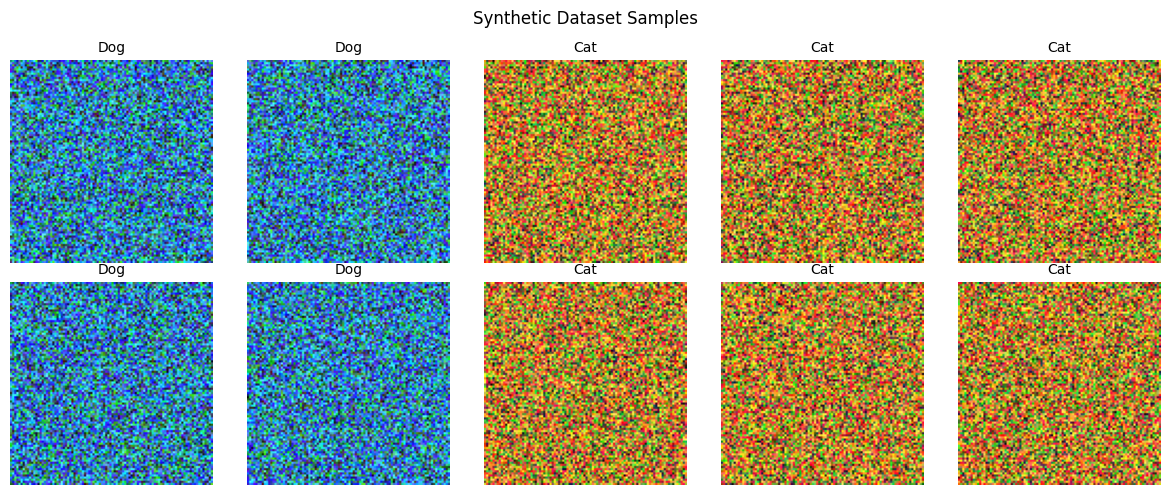

In [3]:
# Visualise a few samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
labels = ['Cat', 'Dog']
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.set_title(labels[y_train[i]], fontsize=10)
    ax.axis('off')
plt.suptitle('Synthetic Dataset Samples')
plt.tight_layout()
plt.show()

In [4]:
# --- Build model with MobileNetV2 base (lightweight, ~14 MB weights) ---
# NOTE: swap base_model to VGG16 or ResNet50 if you have GPU + more time:
#   from tensorflow.keras.applications import VGG16
#   base_model = VGG16(weights='imagenet', include_top=False, input_shape=(96,96,3))

base_model = MobileNetV2(weights='imagenet', include_top=False,
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False   # freeze: feature extraction only

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
# MobileNetV2 expects [-1, 1] — preprocess inside the model
x = keras.applications.mobilenet_v2.preprocess_input(inputs * 255.)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs, name='MobileNetV2_Transfer')
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
print('--- Phase 1: Feature Extraction (base frozen) ---')
history = model.fit(train_ds, epochs=5, validation_data=val_ds, verbose=1)

--- Phase 1: Feature Extraction (base frozen) ---
Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 402ms/step - accuracy: 0.9563 - loss: 0.0804 - val_accuracy: 1.0000 - val_loss: 5.8353e-05
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - accuracy: 1.0000 - loss: 2.0921e-04 - val_accuracy: 1.0000 - val_loss: 1.9253e-05
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step - accuracy: 1.0000 - loss: 7.6727e-05 - val_accuracy: 1.0000 - val_loss: 1.4382e-05
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - accuracy: 1.0000 - loss: 6.5616e-05 - val_accuracy: 1.0000 - val_loss: 1.2129e-05
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step - accuracy: 1.0000 - loss: 1.3799e-04 - val_accuracy: 1.0000 - val_loss: 1.0446e-05


In [6]:
# --- Phase 2: Fine-tune top layers of base ---
base_model.trainable = True
# Freeze everything except the last 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(optimizer=keras.optimizers.Adam(1e-5),
              loss='binary_crossentropy', metrics=['accuracy'])

print(f'Trainable layers after unfreezing: {sum(1 for l in model.layers if l.trainable)}')
print('--- Phase 2: Fine-tuning (top layers unfrozen) ---')
history_ft = model.fit(train_ds, epochs=5, validation_data=val_ds, verbose=1)
print('Fine-tuning complete.')

Trainable layers after unfreezing: 6
--- Phase 2: Fine-tuning (top layers unfrozen) ---
Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 32s 316ms/step - accuracy: 0.9250 - loss: 0.1762 - val_accuracy: 1.0000 - val_loss: 5.1545e-06
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - accuracy: 0.9781 - loss: 0.0639 - val_accuracy: 1.0000 - val_loss: 3.4118e-06
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - accuracy: 1.0000 - loss: 0.0244 - val_accuracy: 1.0000 - val_loss: 2.6739e-06
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 1.0000 - loss: 0.0307 - val_accuracy: 1.0000 - val_loss: 2.1762e-06
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step - accuracy: 0.9969 - loss: 0.0162 - val_accuracy: 1.0000 - val_loss: 1.8248e-06
Fine-tuning complete.


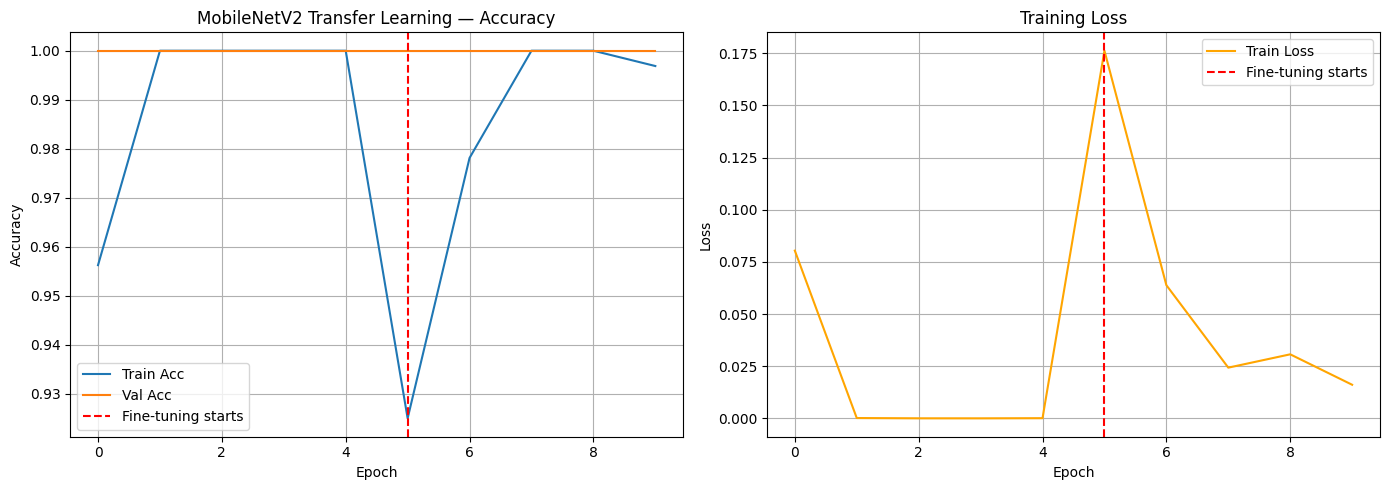

Final Val Accuracy: 1.0000


In [7]:
acc     = history.history['accuracy']     + history_ft.history['accuracy']
val_acc = history.history['val_accuracy'] + history_ft.history['val_accuracy']
loss    = history.history['loss']         + history_ft.history['loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(acc,     label='Train Acc')
ax1.plot(val_acc, label='Val Acc')
ax1.axvline(x=5, color='red', linestyle='--', label='Fine-tuning starts')
ax1.set_title('MobileNetV2 Transfer Learning — Accuracy')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True)

ax2.plot(loss, label='Train Loss', color='orange')
ax2.axvline(x=5, color='red', linestyle='--', label='Fine-tuning starts')
ax2.set_title('Training Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

val_loss, val_acc_final = model.evaluate(val_ds, verbose=0)
print(f'Final Val Accuracy: {val_acc_final:.4f}')

In [8]:
plt.savefig("plot.png")

<Figure size 640x480 with 0 Axes>

## Using Your Own Dataset
To run on real Cats vs Dogs images, replace the synthetic data section with:
```python
from tensorflow.keras.preprocessing.image import ImageDataGenerator
gen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
train_ds = gen.flow_from_directory('your_data/', target_size=(96,96),
                                    batch_size=16, subset='training')
val_ds   = gen.flow_from_directory('your_data/', target_size=(96,96),
                                    batch_size=16, subset='validation')
```
